# V1 — Scales of Evaluation

A single aggregate RMSE often hides the *shape* of model error. This
notebook ties the three V1 operators together on **two real Copernicus
Marine products** over the Gulf Stream:

| Role | Product | Variable | Native resolution |
|------|---------|----------|-------------------|
| **Reference (truth)** | GLORYS12V1 ocean reanalysis (`GLOBAL_MULTIYEAR_PHY_001_030`) | `zos` (sea surface height) | 1/12° (~9 km) |
| **Model** | DUACS L4 reprocessed altimetry (`SEALEVEL_GLO_PHY_L4_MY_008_047`) | `adt` (absolute dynamic topography) | 1/8° (~14 km) |

The two products use different references (DUACS ADT = SLA + MDT;
GLORYS `zos` = SSH above geoid), so we **subtract the per-timestep
spatial mean from each** to compare anomaly fields rather than absolute
values. We also regrid the higher-resolution GLORYS onto the DUACS
grid (rather than the other way around) — coarsening the truth to the
observation grid avoids fabricating fine scales the lower-resolution
DUACS doesn't actually resolve.

Each preprocessing path is expressed as an `xr_toolz` `Sequential`
pipeline so the operator config is introspectable end to end. The V1
metrics then run on the two outputs:

1. `EvaluateByRegion` — split skill by Gulf Stream core / shelf / offshore.
2. `SkillByLeadTime` — skill across the 15 days of the window.
3. `FrequencyBandSkill` — mesoscale (50–500 km) vs submesoscale (10–50 km).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from xr_toolz import Sequential, Signature
from xr_toolz.geo.operators import (
    RemoveMean,
    RenameVariables,
    SelectVariables,
    ValidateCoords,
)
from xr_toolz.interpolate.operators import RegridLike
from xr_toolz.metrics import (
    RMSE,
    BandLimitedRMSE,
    EvaluateByRegion,
    SkillByLeadTime,
    rmse,
)

## 1 — Load the two products

Cached netCDFs cover 2023-06-01 → 2023-06-15 over `[-70, -50] × [30, 45]`.
Section 8 has the `copernicusmarine` snippets for rebuilding the cache
(requires CMEMS credentials in `.env`).

In [2]:
DUACS_CACHE = Path("../../.cache/duacs_gulfstream_2023-06.nc")
GLORYS_CACHE = Path("../../.cache/glorys12_gulfstream_2023-06.nc")

ds_duacs_raw = xr.open_dataset(DUACS_CACHE).load()
ds_glorys_raw = xr.open_dataset(GLORYS_CACHE).load()
print("DUACS:", dict(ds_duacs_raw.sizes), "vars:", list(ds_duacs_raw.data_vars))
print("GLORYS:", dict(ds_glorys_raw.sizes), "vars:", list(ds_glorys_raw.data_vars))

DUACS: {'time': 15, 'latitude': 120, 'longitude': 160} vars: ['adt']
GLORYS: {'time': 15, 'latitude': 181, 'longitude': 241} vars: ['zos']


## 2 — Preprocessing pipelines

Both pipelines compose entirely from operators shipped in `xr_toolz`:

| Operator | Role |
|----------|------|
| `SelectVariables` | drop unused vars |
| `ValidateCoords` | rename `latitude/longitude` → `lat/lon`, attach CF units |
| `RenameVariables` | give the variable a common name (`ssh`) so both pipelines speak the same vocabulary |
| `RegridLike` | bilinear regrid onto another Dataset's `(lat, lon)` grid |
| `RemoveMean` | subtract per-timestep spatial mean (cheap anomaly without climatology) |

In [3]:
# Build the model pipeline first so its grid can be the regrid target
# for the truth pipeline.
duacs_pipeline = Sequential(
    [
        SelectVariables(["adt"]),
        ValidateCoords(),
        RenameVariables({"adt": "ssh"}),
        RemoveMean(("lat", "lon")),
    ]
)

ds_model = duacs_pipeline(ds_duacs_raw)
glorys_pipeline = Sequential(
    [
        SelectVariables(["zos"]),
        ValidateCoords(),
        RenameVariables({"zos": "ssh"}),
        RegridLike(ds_model),
        RemoveMean(("lat", "lon")),
    ]
)

ds_truth = glorys_pipeline(ds_glorys_raw)

print("DUACS model pipeline (structure + shapes):")
print(duacs_pipeline.describe())
print()
duacs_signature = Signature(
    dict(ds_duacs_raw.sizes), dtype=str(ds_duacs_raw["adt"].dtype),
)
print(duacs_pipeline.summary(duacs_signature))
print()
print("GLORYS truth pipeline (structure + shapes):")
print(glorys_pipeline.describe())
print()
glorys_signature = Signature(
    dict(ds_glorys_raw.sizes), dtype=str(ds_glorys_raw["zos"].dtype),
)
print(glorys_pipeline.summary(glorys_signature))

DUACS model pipeline (structure + shapes):
Sequential (4 ops)
├── SelectVariables(variables=['adt'])
├── ValidateCoords()
├── RenameVariables(mapping={'adt': 'ssh'})
└── RemoveMean(dims=['lat', 'lon'])

Sequential (4 ops)
Step  Operator                                 Input Signature                                        Output Signature                                     
----  ---------------------------------------  -----------------------------------------------------  -----------------------------------------------------
0     SelectVariables(variables=['adt'])       (time=15, latitude=120, longitude=160); dtype=float64  (time=15, latitude=120, longitude=160); dtype=float64
1     ValidateCoords()                         (time=15, latitude=120, longitude=160); dtype=float64  (time=15, lat=120, lon=160); dtype=float64           
2     RenameVariables(mapping={'adt': 'ssh'})  (time=15, lat=120, lon=160); dtype=float64             (time=15, lat=120, lon=160); dtype=float64          

Pick a single day so the spatial-skill demos run on a 2D field; keep
the full multi-day window for the lead-time demo.

Aggregate RMSE (m): 0.1246


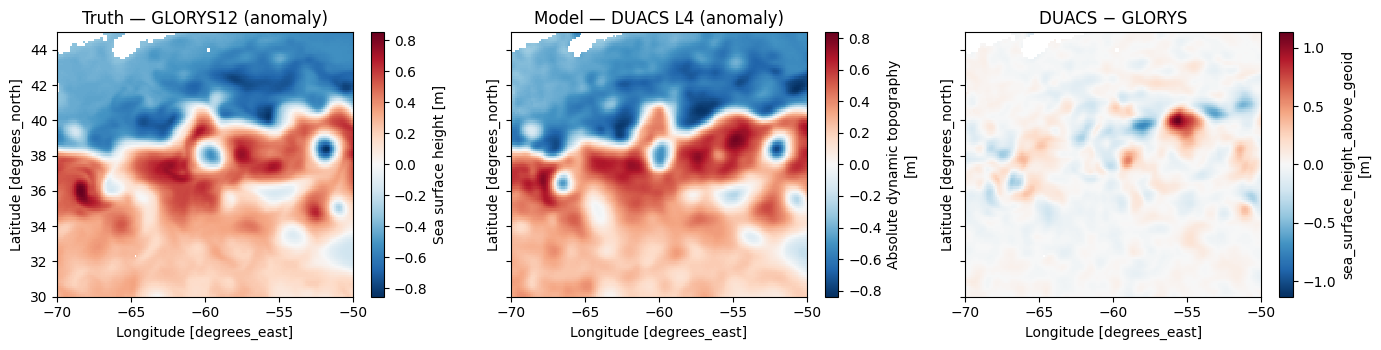

In [4]:
ds_truth_day = (
    ds_truth.isel(time=7).reset_coords("time", drop=False).drop_vars("time")
)
ds_model_day = (
    ds_model.isel(time=7).reset_coords("time", drop=False).drop_vars("time")
)
aggregate_rmse = float(
    rmse(ds_model_day, ds_truth_day, variable="ssh", dims=("lat", "lon"))
)
print(f"Aggregate RMSE (m): {aggregate_rmse:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
ds_truth_day["ssh"].plot(ax=axes[0], cmap="RdBu_r")
axes[0].set_title("Truth — GLORYS12 (anomaly)")
ds_model_day["ssh"].plot(ax=axes[1], cmap="RdBu_r")
axes[1].set_title("Model — DUACS L4 (anomaly)")
(ds_model_day["ssh"] - ds_truth_day["ssh"]).plot(ax=axes[2], cmap="RdBu_r")
axes[2].set_title("DUACS − GLORYS")
fig.tight_layout()
plt.show()

## 3 — `EvaluateByRegion` — Gulf Stream core / shelf / offshore

Three latitude-band masks roughly tracking the GS jet core (35–40 °N),
the shelf (north of jet), and the offshore (south of jet).

In [5]:
core = (ds_truth_day["lat"] >= 35.0) & (ds_truth_day["lat"] <= 40.0)
shelf = ds_truth_day["lat"] > 40.0
offshore = ds_truth_day["lat"] < 35.0
core_b = core.broadcast_like(ds_truth_day["ssh"]).astype(bool)
shelf_b = shelf.broadcast_like(ds_truth_day["ssh"]).astype(bool)
offshore_b = offshore.broadcast_like(ds_truth_day["ssh"]).astype(bool)

region_op = EvaluateByRegion(
    metric=RMSE("ssh", dims=("lat", "lon")),
    regions={"core": core_b, "shelf": shelf_b, "offshore": offshore_b},
)
region_skill = region_op(ds_model_day, ds_truth_day)
print(region_skill)

<xarray.Dataset> Size: 120B
Dimensions:  (region: 3)
Coordinates:
  * region   (region) <U8 96B 'core' 'shelf' 'offshore'
Data variables:
    ssh      (region) float64 24B 0.1701 0.1245 0.04687


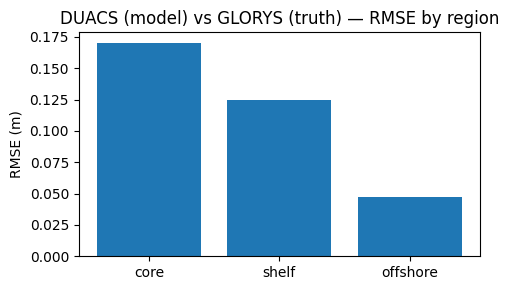

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(region_skill["region"].values.astype(str), region_skill["ssh"].values)
ax.set_ylabel("RMSE (m)")
ax.set_title("DUACS (model) vs GLORYS (truth) — RMSE by region")
fig.tight_layout()
plt.show()

## 4 — `SkillByLeadTime` — skill across the 15-day window

The "lead_time" dim here is just calendar time across the window — a
stand-in for forecast lead. Each daily slice is scored independently.

In [7]:
truth_leads = ds_truth.rename({"time": "lead_time"})
model_leads = ds_model.rename({"time": "lead_time"})

lead_op = SkillByLeadTime(RMSE("ssh", dims=("lat", "lon")))
lead_skill = lead_op(model_leads, truth_leads)
print(lead_skill)

<xarray.DataArray 'ssh' (lead_time: 15)> Size: 120B
array([0.11285044, 0.11079514, 0.10976455, 0.11011367, 0.11197797,
       0.11622509, 0.12183196, 0.12464292, 0.12518927, 0.12337096,
       0.1207528 , 0.11749359, 0.11524241, 0.11473888, 0.11446557])
Coordinates:
  * lead_time  (lead_time) datetime64[ns] 120B 2023-06-01 ... 2023-06-15
Attributes:
    comment:        The absolute dynamic topography is the sea surface height...
    grid_mapping:   crs
    long_name:      Absolute dynamic topography
    standard_name:  sea_surface_height_above_geoid
    units:          m


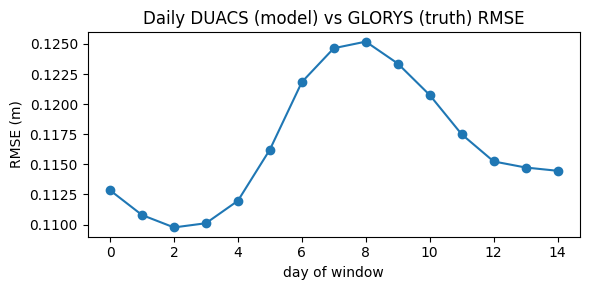

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.arange(lead_skill.sizes["lead_time"]), lead_skill.values, marker="o")
ax.set_xlabel("day of window")
ax.set_ylabel("RMSE (m)")
ax.set_title("Daily DUACS (model) vs GLORYS (truth) RMSE")
fig.tight_layout()
plt.show()

## 5 — `FrequencyBandSkill` — mesoscale vs submesoscale

Bands are `{name: (low, high)}` in **physical** units of the dim coords.
The lat/lon coords carry `units="degrees_north"` / `"degrees_east"`, so
the operator converts spacing to kilometres internally — bands are
therefore in **cycles/km**. The mesoscale band catches wavelengths
50–500 km; the submesoscale band 10–50 km.

In [9]:
spatial_bands = {
    "mesoscale": (1.0 / 500.0, 1.0 / 50.0),
    "submesoscale": (1.0 / 50.0, 1.0 / 10.0),
}
band_op = BandLimitedRMSE("ssh", ("lat", "lon"), spatial_bands)
band_skill = band_op(ds_model_day, ds_truth_day)
print(band_skill)

<xarray.Dataset> Size: 144B
Dimensions:    (band: 2)
Coordinates:
  * band       (band) <U12 96B 'mesoscale' 'submesoscale'
    band_low   (band) float64 16B 0.002 0.02
    band_high  (band) float64 16B 0.02 0.1
Data variables:
    ssh        (band) float64 16B 0.1102 0.01037


Absolute band-limited RMSE depends on the variance available in each
band. Normalise by the truth's in-band RMS to see *fraction of in-band
variance the model fails to reproduce*.

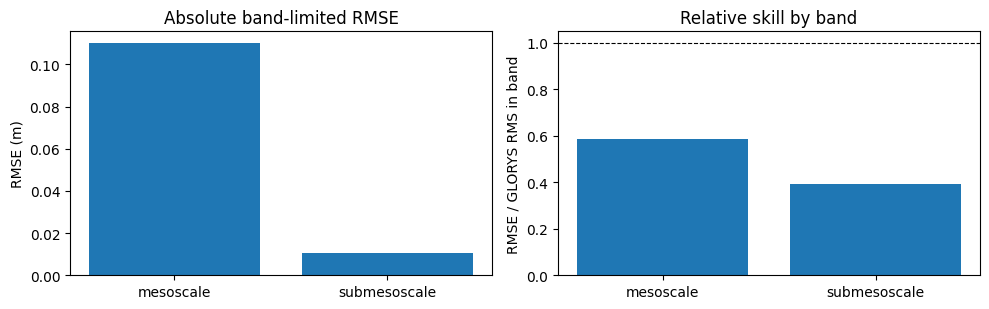

In [10]:
truth_band_rms = BandLimitedRMSE("ssh", ("lat", "lon"), spatial_bands)(
    xr.zeros_like(ds_truth_day), ds_truth_day
)
relative_skill = band_skill["ssh"] / truth_band_rms["ssh"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].bar(band_skill["band"].values.astype(str), band_skill["ssh"].values)
axes[0].set_ylabel("RMSE (m)")
axes[0].set_title("Absolute band-limited RMSE")
axes[1].bar(relative_skill["band"].values.astype(str), relative_skill.values)
axes[1].set_ylabel("RMSE / GLORYS RMS in band")
axes[1].set_title("Relative skill by band")
axes[1].axhline(1.0, color="k", linestyle="--", linewidth=0.8)
fig.tight_layout()
plt.show()

## 6 — Stacked summary

Three views, one comparison: a single aggregate RMSE conceals where
and at what scale the model deviates from the observation-based
reference.

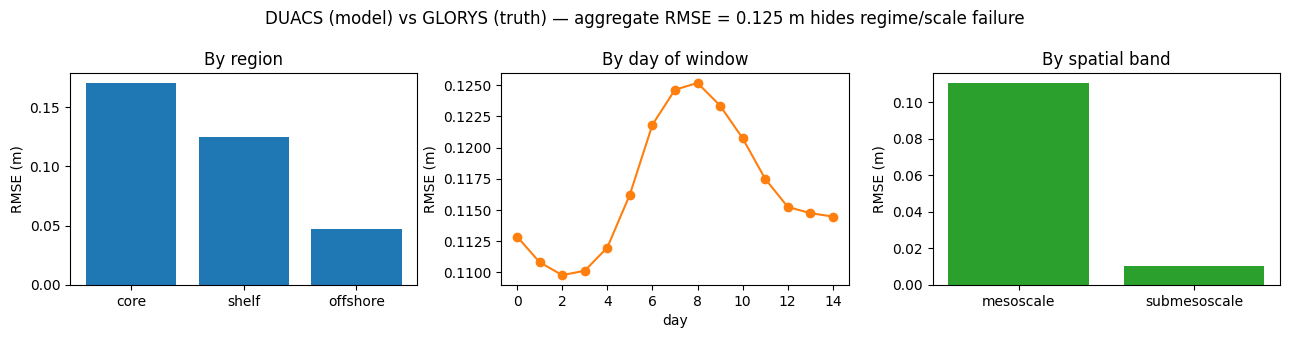

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].bar(
    region_skill["region"].values.astype(str),
    region_skill["ssh"].values,
    color="C0",
)
axes[0].set_title("By region")
axes[0].set_ylabel("RMSE (m)")
axes[1].plot(
    np.arange(lead_skill.sizes["lead_time"]),
    lead_skill.values,
    marker="o",
    color="C1",
)
axes[1].set_title("By day of window")
axes[1].set_xlabel("day")
axes[1].set_ylabel("RMSE (m)")
axes[2].bar(
    band_skill["band"].values.astype(str), band_skill["ssh"].values, color="C2"
)
axes[2].set_title("By spatial band")
axes[2].set_ylabel("RMSE (m)")
fig.suptitle(
    f"DUACS (model) vs GLORYS (truth) — aggregate RMSE = {aggregate_rmse:.3f} m hides regime/scale failure"
)
fig.tight_layout()
plt.show()

## 7 — Operator configs are JSON-serializable

Both pipelines and every metric operator round-trip through
`get_config()` to JSON — useful when attaching a validation graph to a
model artifact.

In [12]:
import json

print(json.dumps(band_op.get_config(), indent=2))

{
  "variable": "ssh",
  "dims": [
    "lat",
    "lon"
  ],
  "bands": {
    "mesoscale": [
      0.002,
      0.02
    ],
    "submesoscale": [
      0.02,
      0.1
    ]
  },
  "metric": {
    "class": "RMSE",
    "config": {
      "variable": "ssh",
      "dims": [
        "lat",
        "lon"
      ]
    }
  }
}


## 8 — Rebuilding the cache

The cells below download both slices from CMEMS via `copernicusmarine`.
Skip them if `.cache/duacs_gulfstream_2023-06.nc` and
`.cache/glorys12_gulfstream_2023-06.nc` already exist. Requires
`COPERNICUSMARINE_SERVICE_USERNAME` and
`COPERNICUSMARINE_SERVICE_PASSWORD` in `.env`.

```python
from dotenv import load_dotenv
import copernicusmarine as cm
load_dotenv()
bbox = dict(
    minimum_longitude=-70.0, maximum_longitude=-50.0,
    minimum_latitude=30.0,   maximum_latitude=45.0,
)
window = dict(start_datetime="2023-06-01", end_datetime="2023-06-15")

duacs = cm.open_dataset(
    dataset_id="cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D",
    variables=["adt"], **bbox, **window,
).load()
duacs.to_netcdf(".cache/duacs_gulfstream_2023-06.nc")

glorys = cm.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["zos"], **bbox, **window,
).load()
glorys.to_netcdf(".cache/glorys12_gulfstream_2023-06.nc")
```